# Color Advantage Analysis

This notebook analyzes the statistical advantage of playing White versus Black in chess using a dataset of 20,058 games from Lichess.org.

## Objectives
- Quantify the first-move advantage through win rate analysis
- Test statistical significance using chi-square tests and confidence intervals
- Calculate effect sizes to assess practical significance
- Control for rating differences to isolate the pure color advantage

## Key Findings Preview
- White wins 4.46 percentage points more often than Black (statistically significant, p < 0.001)
- Effect size is negligible (Cohen's h = 0.09), indicating limited practical impact
- The advantage persists in rating-balanced games (~3 percentage points)

In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm

## 1. Data Preparation
Loading the chess games dataset from Lichess.org containing over 20,000 games.

In [46]:
df = pd.read_csv('../data/games.csv')

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              20058 non-null  str    
 1   rated           20058 non-null  bool   
 2   created_at      20058 non-null  float64
 3   last_move_at    20058 non-null  float64
 4   turns           20058 non-null  int64  
 5   victory_status  20058 non-null  str    
 6   winner          20058 non-null  str    
 7   increment_code  20058 non-null  str    
 8   white_id        20058 non-null  str    
 9   white_rating    20058 non-null  int64  
 10  black_id        20058 non-null  str    
 11  black_rating    20058 non-null  int64  
 12  moves           20058 non-null  str    
 13  opening_eco     20058 non-null  str    
 14  opening_name    20058 non-null  str    
 15  opening_ply     20058 non-null  int64  
dtypes: bool(1), float64(2), int64(4), str(9)
memory usage: 2.3 MB


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


## 2. Feature Selection
Selecting relevant columns for color advantage analysis and creating a focused dataset.

In [47]:
# Keep only the relevant columns
columns_to_keep = [
    'id',
    'winner',
    'white_id',
    'white_rating',
    'black_id',
    'black_rating',
    'turns'
]

color_df = df[columns_to_keep].copy()

# Calculate rating difference and rating balance categories
color_df['rating_diff'] = color_df['white_rating'] - color_df['black_rating']

def categorize_rating_balance(diff):
    """Categorize games by rating difference"""
    if abs(diff) < 50:
        return 'Balanced (<50)'
    elif abs(diff) < 100:
        return 'Slight Gap (50-100)'
    elif abs(diff) < 200:
        return 'Moderate Gap (100-200)'
    else:
        return 'Large Gap (200+)'

color_df['rating_balance'] = color_df['rating_diff'].apply(categorize_rating_balance)

color_df.info()
color_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   id              20058 non-null  str  
 1   winner          20058 non-null  str  
 2   white_id        20058 non-null  str  
 3   white_rating    20058 non-null  int64
 4   black_id        20058 non-null  str  
 5   black_rating    20058 non-null  int64
 6   turns           20058 non-null  int64
 7   rating_diff     20058 non-null  int64
 8   rating_balance  20058 non-null  str  
dtypes: int64(4), str(5)
memory usage: 1.4 MB


,id,winner,white_id,white_rating,black_id,black_rating,turns,rating_diff,rating_balance
0,TZJHLljE,white,bourgris,1500,a-00,1191,13,309,Large Gap (200+)
1,l1NXvwaE,black,a-00,1322,skinnerua,1261,16,61,Slight Gap (50-100)
2,mIICvQHh,white,ischia,1496,a-00,1500,61,-4,Balanced (<50)
3,kWKvrqYL,white,daniamurashov,1439,adivanov2009,1454,61,-15,Balanced (<50)
4,9tXo1AUZ,white,nik221107,1523,adivanov2009,1469,95,54,Slight Gap (50-100)


## 3. Basic Win Rate Analysis
Calculating the overall win rates for White, Black, and draws across all games.

GAME OUTCOME DISTRIBUTION
        Count  Percentage
winner                   
white   10001   49.860405
black    9107   45.403330
draw      950    4.736265

Total Games: 20,058


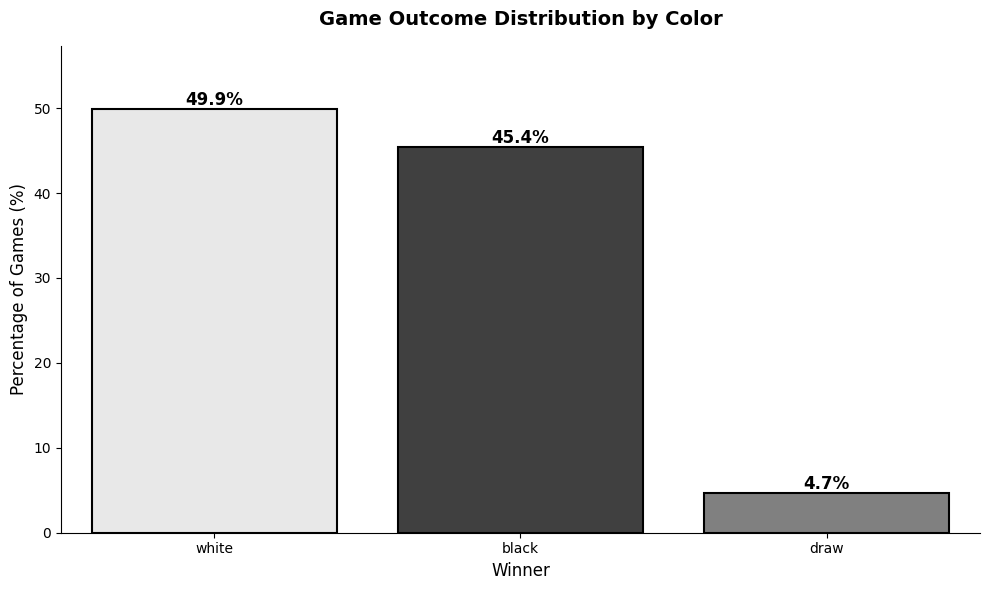

In [48]:
# Calculate outcome counts and percentages
outcome_counts = color_df['winner'].value_counts()
outcome_pct = color_df['winner'].value_counts(normalize=True) * 100

# Create summary dataframe
outcome_summary = pd.DataFrame({
    'Count': outcome_counts,
    'Percentage': outcome_pct
})

print("="*60)
print("GAME OUTCOME DISTRIBUTION")
print("="*60)
print(outcome_summary)
print(f"\nTotal Games: {len(color_df):,}")

# Visualize win rates using Seaborn
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data for Seaborn
outcomes_data = pd.DataFrame({
    'Winner': outcome_pct.index,
    'Percentage': outcome_pct.values
})

colors_map = {'white': '#E8E8E8', 'black': '#404040', 'draw': '#808080'}
bar_colors = [colors_map.get(x, '#808080') for x in outcomes_data['Winner']]

sns.barplot(
    data=outcomes_data,
    x='Winner',
    y='Percentage',
    hue='Winner',
    palette=bar_colors,
    edgecolor='black',
    linewidth=1.5,
    legend=False,
    ax=ax
)

# Add percentage labels on bars
for i, (idx, row) in enumerate(outcomes_data.iterrows()):
    ax.text(i, row['Percentage'], f"{row['Percentage']:.1f}%",
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Game Outcome Distribution by Color', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Winner', fontsize=12)
ax.set_ylabel('Percentage of Games (%)', fontsize=12)
ax.set_ylim(0, outcomes_data['Percentage'].max() * 1.15)

sns.despine()

plt.tight_layout()
plt.savefig('../images/01_color_advantage_analysis/outcome_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Statistical Significance Testing
Testing whether the observed differences in win rates are statistically significant using chi-square test and calculating confidence intervals.

In [49]:
# Perform chi-square test
white_wins = (color_df['winner'] == 'white').sum()
black_wins = (color_df['winner'] == 'black').sum()
total_decisive = white_wins + black_wins

# Expected values under null hypothesis (50-50 split)
expected = total_decisive / 2
observed = np.array([white_wins, black_wins])

chi2_stat = np.sum((observed - expected)**2 / expected)
p_value = 1 - stats.chi2.cdf(chi2_stat, df=1)

# Calculate confidence intervals using Wilson score interval
# Wilson CI is more accurate than normal approximation for proportions
def wilson_ci(successes, total, confidence=0.95):
    """Calculate Wilson score confidence interval for a proportion"""
    z = norm.ppf((1 + confidence) / 2)
    p_hat = successes / total
    denominator = 1 + z**2 / total
    center = (p_hat + z**2 / (2 * total)) / denominator
    margin = z * np.sqrt((p_hat * (1 - p_hat) + z**2 / (4 * total)) / total) / denominator
    return center - margin, center + margin

total_games = len(color_df)
white_win_rate = white_wins / total_games * 100
black_win_rate = black_wins / total_games * 100
draw_rate = (color_df['winner'] == 'draw').sum() / total_games * 100

white_ci = wilson_ci(white_wins, total_games)
black_ci = wilson_ci(black_wins, total_games)

print("="*60)
print("STATISTICAL SIGNIFICANCE TESTING")
print("="*60)
print(f"\nWin Rates:")
print(f"  White: {white_win_rate:.2f}% (95% CI: {white_ci[0]*100:.2f}%-{white_ci[1]*100:.2f}%)")
print(f"  Black: {black_win_rate:.2f}% (95% CI: {black_ci[0]*100:.2f}%-{black_ci[1]*100:.2f}%)")
print(f"  Draw:  {draw_rate:.2f}%")
print(f"\nChi-Square Test (White vs Black wins):")
print(f"  χ² statistic: {chi2_stat:.2f}")
print(f"  p-value: {p_value:.6f}")
print(f"  Degrees of freedom: 1")

if p_value < 0.001:
    print(f"  Result: HIGHLY SIGNIFICANT (p < 0.001)")
elif p_value < 0.05:
    print(f"  Result: SIGNIFICANT (p < 0.05)")
else:
    print(f"  Result: NOT SIGNIFICANT (p >= 0.05)")

print(f"\nInterpretation:")
if white_win_rate > black_win_rate:
    diff = white_win_rate - black_win_rate
    print(f"  White wins {diff:.2f} percentage points more often than Black.")
else:
    diff = black_win_rate - white_win_rate
    print(f"  Black wins {diff:.2f} percentage points more often than White.")

STATISTICAL SIGNIFICANCE TESTING

Win Rates:
  White: 49.86% (95% CI: 49.17%-50.55%)
  Black: 45.40% (95% CI: 44.72%-46.09%)
  Draw:  4.74%

Chi-Square Test (White vs Black wins):
  χ² statistic: 41.83
  p-value: 0.000000
  Degrees of freedom: 1
  Result: HIGHLY SIGNIFICANT (p < 0.001)

Interpretation:
  White wins 4.46 percentage points more often than Black.


## 5. Effect Size and Practical Significance
Calculating effect sizes to understand the practical magnitude of the first-move advantage.

In [50]:
# Calculate effect sizes
# Cohen's h for comparing two proportions
p1 = white_wins / total_games  # White win rate
p2 = black_wins / total_games  # Black win rate

# Cohen's h formula
cohens_h = 2 * (np.arcsin(np.sqrt(p1)) - np.arcsin(np.sqrt(p2)))

# Cramér's V for chi-square test
n = total_games
cramers_v = np.sqrt(chi2_stat / n)

# Odds ratio
odds_white = white_wins / black_wins
odds_ratio = odds_white

print("="*60)
print("EFFECT SIZE ANALYSIS")
print("="*60)
print(f"\nCohen's h: {cohens_h:.4f}")
print(f"  Interpretation: ", end="")
if abs(cohens_h) < 0.2:
    print("Negligible effect")
elif abs(cohens_h) < 0.5:
    print("Small effect")
elif abs(cohens_h) < 0.8:
    print("Medium effect")
else:
    print("Large effect")

print(f"\nCramér's V: {cramers_v:.4f}")
print(f"  Interpretation: ", end="")
if cramers_v < 0.1:
    print("Negligible association")
elif cramers_v < 0.3:
    print("Weak association")
elif cramers_v < 0.5:
    print("Moderate association")
else:
    print("Strong association")

print(f"\nOdds Ratio: {odds_ratio:.4f}")
print(f"  Interpretation: White is {odds_ratio:.2f}x as likely to win as Black")

print(f"\n{'='*60}")
print("PRACTICAL SIGNIFICANCE")
print("="*60)
print(f"\nWhile the difference is statistically significant (p < 0.001),")
print(f"the effect size is {abs(cohens_h):.4f} (Cohen's h), which is considered")
print(f"{'negligible' if abs(cohens_h) < 0.2 else 'small' if abs(cohens_h) < 0.5 else 'medium'}.")
print(f"\nThis means that while White does have a measurable advantage,")
print(f"the practical impact on individual game outcomes is limited.")
print(f"Other factors (player skill, preparation, psychology) likely")
print(f"have much larger effects on game results.")

EFFECT SIZE ANALYSIS

Cohen's h: 0.0893
  Interpretation: Negligible effect

Cramér's V: 0.0457
  Interpretation: Negligible association

Odds Ratio: 1.0982
  Interpretation: White is 1.10x as likely to win as Black

PRACTICAL SIGNIFICANCE

While the difference is statistically significant (p < 0.001),
the effect size is 0.0893 (Cohen's h), which is considered
negligible.

This means that while White does have a measurable advantage,
the practical impact on individual game outcomes is limited.
Other factors (player skill, preparation, psychology) likely
have much larger effects on game results.


## 6. Rating-Adjusted Color Advantage
Controlling for player skill differences to isolate the pure effect of playing White vs Black.

RATING-ADJUSTED ANALYSIS (Balanced Games Only)

Balanced Games (rating diff < 50): 5,383

Win Rates in Balanced Games:
  White: 48.78%
  Black: 45.85%
  Draw:  5.37%

First-move advantage in balanced games: +2.94 percentage points

Win Rates by Rating Balance:
winner                  black  draw  white
rating_balance                            
Balanced (<50)          45.85  5.37  48.78
Large Gap (200+)        45.26  3.81  50.93
Moderate Gap (100-200)  45.49  4.83  49.68
Slight Gap (50-100)     44.90  5.29  49.81


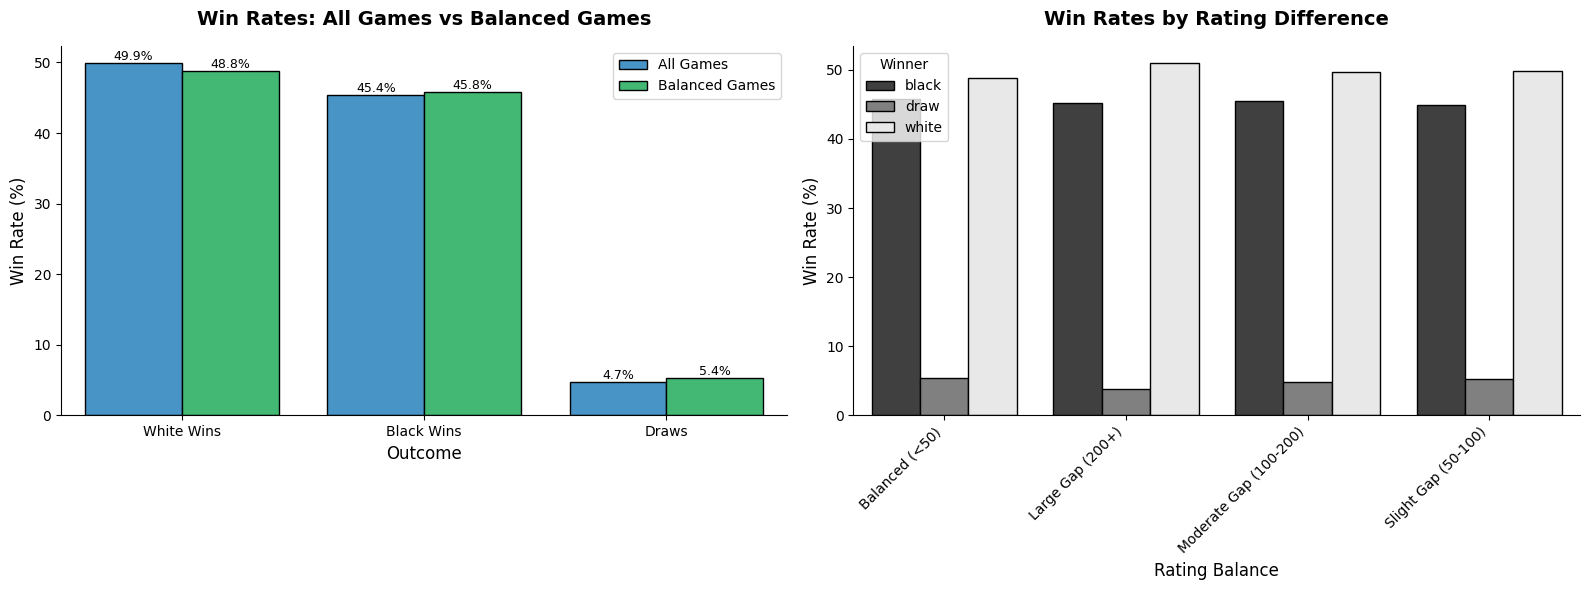

In [51]:
# Analyze win rates in balanced games (rating difference < 50)
balanced_games = color_df[abs(color_df['rating_diff']) < 50].copy()

balanced_white_wins = (balanced_games['winner'] == 'white').sum()
balanced_black_wins = (balanced_games['winner'] == 'black').sum()
balanced_draws = (balanced_games['winner'] == 'draw').sum()
balanced_total = len(balanced_games)

balanced_white_rate = balanced_white_wins / balanced_total * 100
balanced_black_rate = balanced_black_wins / balanced_total * 100
balanced_draw_rate = balanced_draws / balanced_total * 100

print("="*60)
print("RATING-ADJUSTED ANALYSIS (Balanced Games Only)")
print("="*60)
print(f"\nBalanced Games (rating diff < 50): {balanced_total:,}")
print(f"\nWin Rates in Balanced Games:")
print(f"  White: {balanced_white_rate:.2f}%")
print(f"  Black: {balanced_black_rate:.2f}%")
print(f"  Draw:  {balanced_draw_rate:.2f}%")

if balanced_white_rate > balanced_black_rate:
    advantage = balanced_white_rate - balanced_black_rate
    print(f"\nFirst-move advantage in balanced games: +{advantage:.2f} percentage points")

# Analyze win rates by rating balance category
rating_balance_analysis = color_df.groupby('rating_balance')['winner'].value_counts(normalize=True).unstack(fill_value=0) * 100

print(f"\n{'='*60}")
print("Win Rates by Rating Balance:")
print(rating_balance_analysis.round(2))

# Visualize rating-adjusted analysis using Seaborn
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Comparison - All games vs Balanced games
comparison_data = pd.DataFrame({
    'Outcome': ['White Wins', 'Black Wins', 'Draws'] * 2,
    'Win Rate (%)': [white_win_rate, black_win_rate, draw_rate, 
                     balanced_white_rate, balanced_black_rate, balanced_draw_rate],
    'Game Type': ['All Games'] * 3 + ['Balanced Games'] * 3
})

sns.barplot(
    data=comparison_data,
    x='Outcome',
    y='Win Rate (%)',
    hue='Game Type',
    palette=['#3498db', '#2ecc71'],
    edgecolor='black',
    linewidth=1,
    ax=ax1
)

# Add value labels
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f%%', fontsize=9)

ax1.set_xlabel('Outcome', fontsize=12)
ax1.set_ylabel('Win Rate (%)', fontsize=12)
ax1.set_title('Win Rates: All Games vs Balanced Games', fontsize=14, fontweight='bold', pad=15)
ax1.legend(title='')
sns.despine(ax=ax1)

# Panel 2: Win rates by rating balance
rating_balance_long = rating_balance_analysis.reset_index().melt(
    id_vars='rating_balance',
    var_name='Winner',
    value_name='Win Rate (%)'
)

sns.barplot(
    data=rating_balance_long,
    x='rating_balance',
    y='Win Rate (%)',
    hue='Winner',
    palette=['#404040', '#808080', '#E8E8E8'],
    edgecolor='black',
    linewidth=1,
    ax=ax2
)

ax2.set_xlabel('Rating Balance', fontsize=12)
ax2.set_ylabel('Win Rate (%)', fontsize=12)
ax2.set_title('Win Rates by Rating Difference', fontsize=14, fontweight='bold', pad=15)
ax2.legend(title='Winner', loc='upper left')
ax2.tick_params(axis='x', rotation=45)
for label in ax2.get_xticklabels():
    label.set_ha('right')
sns.despine(ax=ax2)

plt.tight_layout()
plt.savefig('../images/01_color_advantage_analysis/rating_adjusted_analysis.png', dpi=300, bbox_inches='tight')
plt.show()